# CTD Data Extraction — Barkley Sound, February 2025

A **CTD** (Conductivity–Temperature–Depth) instrument measures seawater properties as it is lowered through the water column.  
This notebook loads raw CTD casts collected in **Barkley Sound** (Bamfield Marine Sciences Centre, British Columbia) in February 2025, using an **AML-6 CTD**.

For each cast we extract only the **downcast** — the portion of the record while the instrument is descending — and then visualise the profiles and a temperature–salinity (T-S) diagram.

**Dataset summary**
- Instrument: AML-6 CTD (temperature, salinity, depth, dissolved oxygen, cDOM fluorescence, pH, sound velocity)
- Location: Barkley Sound, BC (~48.85 °N, 125.15 °W)
- Dates: 18–22 February 2025
- Number of casts: 29

---
**To get started:** edit the `USER CONFIGURATION` cell (just below the imports) to point to your data directory, then run all cells in order (`Kernel → Restart & Run All`).

In [20]:
# Numerical / data
import numpy as np
import pandas as pd

# Plotting
from matplotlib import pyplot as plt
import cmocean          # perceptually-uniform oceanographic colormaps
import seaborn as sns

# Oceanographic calculations
import gsw              # TEOS-10 Gibbs SeaWater toolbox

# Mapping
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# File handling
import glob, os
from netCDF4 import Dataset as netcdf_dataset

In [21]:
# ── USER CONFIGURATION ──────────────────────────────────────────
DATA_DIR   = '/Users/hjb62/Documents/CTD Data/'
#'/Users/hjb62/Python/Teaching/EOAS Teaching/EOSC473:573 Teaching/BamfieldCTD2025/all/'
FILETYPE   = 'aml'
BATHY_FILE = 'barkley_sound_1_navd88_2016.nc'

# Minimum depth (m) at which a cast is considered to have started descending.
# Rows above this depth at the start of a file are treated as the soak period.
SURFACE_THRESHOLD = 2.0

# Dissolved oxygen unit conversion: AML records DO in µmol/L.
# Divide by this factor to convert to mL/L (legacy unit).
DO_CONV = 43.57

# Dissolved oxygen display units.
# Set to 'umol/L' (modern standard) or 'mL/L' (legacy unit).
DO_UNITS = 'umol/L'

# T-S diagram colour variable.
# Set to 'DO' (dissolved oxygen) or 'depth'.
TS_COLOR = 'DO'
# ────────────────────────────────────────────────────────────────

# Derived from DO_UNITS — no need to edit below this line
DO_DIVISOR = DO_CONV if DO_UNITS == 'mL/L' else 1.0
DO_LABEL   = 'DO (mL L\u207b\u00b9)' if DO_UNITS == 'mL/L' else 'DO (\u00b5mol L\u207b\u00b9)'

## File Discovery

The cell below scans `DATA_DIR` for all `.aml` files and sorts them chronologically by the time embedded in each filename.  
The result is `file_list` — an ordered list of file paths, one per cast.

In [22]:
# Extract the time string from a filename for chronological sorting
def grab_time(x):
    return x[-12:-4]

# Scan DATA_DIR for all files with the correct extension and sort chronologically
file_list = glob.glob(os.path.join(DATA_DIR, f'*.{FILETYPE}'))
file_list = sorted(file_list, key=grab_time)

print(f'Found {len(file_list)} cast files.')

Found 8 cast files.


## Importing and Trimming Casts

`importfiles` reads each raw AML file, parses the header to extract GPS coordinates and column names, then trims each cast to its **downcast** only.

**Trimming logic:** before a cast begins, the instrument rests near the surface (the *soak period*).  
We locate the last moment the depth was less than `SURFACE_THRESHOLD` metres before the deepest point, and keep only data from that moment through the maximum depth.

The diagnostic plot in the next cell shows each cast **before** (top) and **after** (bottom) trimming.

In [23]:
def conv_float(x):
    """Convert a string to float, returning NaN if the string is not numeric."""
    return float(x) if (x.replace('.', '', 1).isdigit() or x.lstrip('-').replace('.', '', 1).isdigit()) else float('nan')


def importfiles(file_list, filetype, surface_threshold=2.0):
    """
    Import CTD cast files and trim each record to the downcast only.

    Parameters
    ----------
    file_list : list of str
        Ordered list of file paths returned by the file discovery cell.
    filetype : str
        Instrument file format. Currently only 'aml' is supported.
    surface_threshold : float
        Depth (m) below which the instrument is considered to have left the
        surface. Rows shallower than this at the start of the file are treated
        as the soak period and discarded. Default: 2.0 m.

    Returns
    -------
    df : pd.DataFrame
        All casts concatenated into a single DataFrame (useful for T-S plots).
    dfs : list of pd.DataFrame
        One DataFrame per cast, trimmed to the downcast.
    sample_lons : list of float
        GPS longitude for each cast (NaN if GPS lock was unavailable).
    sample_lats : list of float
        GPS latitude for each cast (NaN if GPS lock was unavailable).
    """
    if filetype == 'aml':
        fig, axs = plt.subplots(nrows=2, figsize=(6, 8), sharex=False)
        axs[0].set_title('Full records')
        axs[1].set_title('Trimmed downcasts')

        dfs = []
        sample_lons = [None] * len(file_list)
        sample_lats = [None] * len(file_list)

        for profile_idx, filepath in enumerate(file_list):
            nameline = np.nan
            header   = np.nan
            units    = []

            # --- Parse the file header ---
            # AML files contain a text header followed by a CSV data block.
            # We scan line-by-line to find:
            #   MeasurementMetadata → the next line lists the column names;
            #                         the line after that lists the units
            #   MeasurementData     → the line number where the data block begins
            #   GPSLatitude / GPSLongitude → station coordinates
            with open(filepath) as fh:
                for i, line in enumerate(fh):
                    if 'MeasurementMetadata' in line:
                        nameline = i
                    elif 'MeasurementData' in line:
                        header = i
                    elif i == nameline + 1:
                        cols = line.strip().split('=', 1)[1].split(',')
                    elif i == nameline + 2:
                        # Units line immediately follows the column names line
                        units = [u.strip() for u in line.strip().split('=', 1)[1].split(',')]
                    elif 'GPSLatitude' in line:
                        lat_str = line.split('=', 1)[1].strip()
                    elif 'GPSLongitude' in line:
                        lon_str = line.split('=', 1)[1].strip()

            # Print column names and units from the first file as a diagnostic
            if profile_idx == 0 and units:
                print('Columns and units (from first file header):')
                for col, unit in zip(cols, units):
                    print(f'  {col}: {unit}')

            sample_lons[profile_idx] = conv_float(lon_str)
            sample_lats[profile_idx] = conv_float(lat_str)

            data = pd.read_csv(filepath, header=header, names=cols)
            data['file']    = filepath.split('log_')[-1].split('_')[-1].split('.')[0]
            data['profile'] = profile_idx

            axs[0].plot(data['Depth'].values)

            # --- Trim to the downcast ---
            # Find the index of the deepest point.
            maxdepth_idx = data['Depth'].idxmax()

            # Among all rows before the maximum depth, find the last row where
            # the instrument was still within surface_threshold of the surface.
            # That row marks the true start of the descent.
            pre_max      = data.loc[:maxdepth_idx]
            near_surface = pre_max[pre_max['Depth'] < surface_threshold]
            cast_start   = near_surface.index[-1] if len(near_surface) > 0 else pre_max.index[0]

            data = data.loc[cast_start:maxdepth_idx].copy()

            axs[1].plot(data['Depth'].values, label=profile_idx)
            dfs.append(data)

        for ax in axs:
            ax.set_ylabel('Depth (m)')
            ax.invert_yaxis()

        df = pd.concat(dfs, ignore_index=True)
        return df, dfs, sample_lons, sample_lats

## Running the Import

The cell below calls `importfiles` on all files in `file_list` and produces a diagnostic plot showing each cast **before** (top panel) and **after** (bottom panel) trimming to the downcast.

Columns and units (from first file header):
  Date: yyyy-mm-dd
  Time: hh:mm:ss.ss
  Cond: mS/cm
  TempCT: C
  DOM: ppb
  Turbidity: NTU
  DO: umol/l
  TempDO: C
  pH: pH
  Pressure: dBar
  Salinity: PSU
  Density: kg/cm3
  CalcSV: m/s
  Depth: m


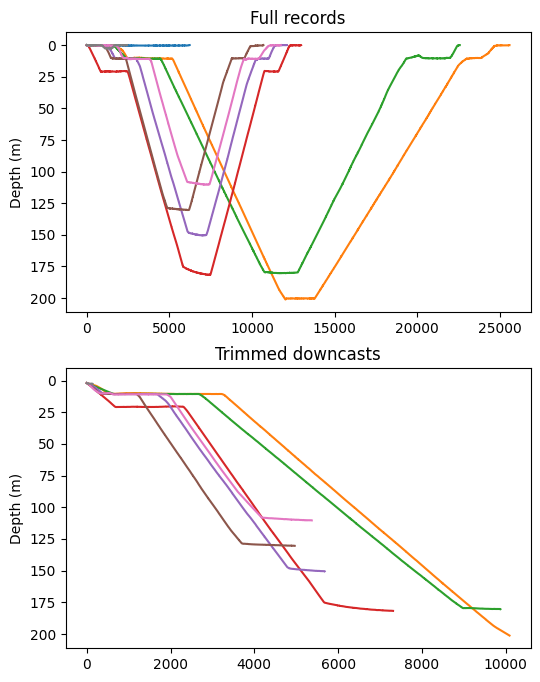

In [24]:
df, dfs, sample_lons, sample_lats = importfiles(file_list, FILETYPE, surface_threshold=SURFACE_THRESHOLD)

# Colour palette — one colour per profile, consistent across all figures.
PROFILE_COLORS = sns.color_palette('Spectral', n_colors=df['profile'].nunique())

The GPS coordinates parsed from each file header are printed below.  
Any `nan` values indicate casts where the instrument did not acquire a GPS fix; those stations are omitted from the map.

In [15]:
print(sample_lons, sample_lats)

[-125.11234, -125.11169, -125.11145, -125.1152, -125.11478] [48.87457, 48.87465, 48.87414, 48.85593, 48.85635]


## TEOS-10 Derived Quantities

The raw AML data uses legacy units: **Practical Salinity** (S_P, dimensionless) and **in-situ temperature** (°C, ITS-90).  
The TEOS-10 standard (IOC 2010) recommends **Absolute Salinity** (S_A, g kg⁻¹) and **Conservative Temperature** (Θ, °C) for all thermodynamic calculations, as these are true conserved quantities under mixing.

The cell below converts to TEOS-10 and adds the following columns to `df`:

| Column | Description |
|--------|-------------|
| `p` | Pressure (dbar), computed from depth and latitude |
| `SA` | Absolute Salinity (g kg⁻¹) |
| `CT` | Conservative Temperature (°C) |
| `sigma0` | Potential density anomaly σ₀ (kg m⁻³), referenced to 0 dbar |

For profile 4 (no GPS fix), `SA`, `CT`, and `sigma0` will be `NaN`.

In [7]:
# Map GPS coordinates onto every row of df using the profile index
lat_map = {i: lat for i, lat in enumerate(sample_lats)}
lon_map = {i: lon for i, lon in enumerate(sample_lons)}
df['lat'] = df['profile'].map(lat_map)
df['lon'] = df['profile'].map(lon_map)

# Pressure from depth (gsw convention: z is negative downward, depth is positive)
df['p'] = gsw.p_from_z(-df['Depth'], df['lat'])

# Absolute Salinity from Practical Salinity
df['SA'] = gsw.SA_from_SP(df['Salinity'], df['p'], df['lon'], df['lat'])

# Conservative Temperature from in-situ temperature
df['CT'] = gsw.CT_from_t(df['SA'], df['TempCT'], df['p'])

# Potential density anomaly referenced to 0 dbar
df['sigma0'] = gsw.sigma0(df['SA'], df['CT'])

print('TEOS-10 conversion complete.')
print(f"  SA range:     {df['SA'].min():.3f} – {df['SA'].max():.3f} g kg\u207b\u00b9")
print(f"  CT range:     {df['CT'].min():.3f} – {df['CT'].max():.3f} \u00b0C")
print(f"  \u03c30 range:    {df['sigma0'].min():.3f} – {df['sigma0'].max():.3f} kg m\u207b\u00b3")

TEOS-10 conversion complete.
  SA range:     28.171 – 33.098 g kg⁻¹
  CT range:     7.332 – 10.277 °C
  σ0 range:    21.860 – 25.586 kg m⁻³


## Station Map

The map below shows the location of each CTD cast in Barkley Sound, overlaid on 2016 multibeam bathymetry.  
Stations are colour-coded by profile number (cast order). The bull's-eye symbol marks Bamfield Marine Sciences Centre (BMSC).

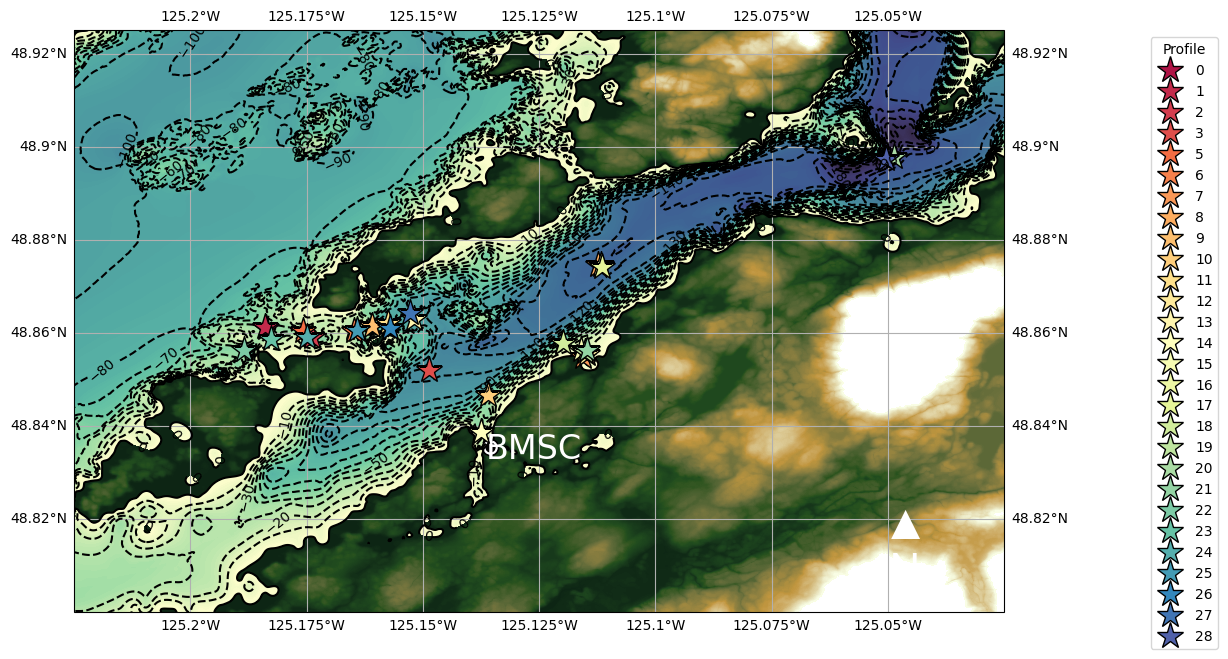

In [8]:
# Load bathymetry dataset
dataset    = netcdf_dataset(BATHY_FILE)
depth_bathy = dataset.variables['Band1'][:, :]
bathy_lats  = dataset.variables['lat'][:]
bathy_lons  = dataset.variables['lon'][:]

map_projection = ccrs.PlateCarree()
fig, ax0 = plt.subplots(figsize=(12, 12), subplot_kw={'projection': map_projection})
ax0.set_extent([-125.225, -125.025, 48.8, 48.925])

# Axis tick formatters
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter  = LatitudeFormatter()
ax0.xaxis.set_major_formatter(lon_formatter)
ax0.yaxis.set_major_formatter(lat_formatter)
ax0.gridlines(draw_labels=True)

# BMSC marker (bull's-eye)
BMSC_lat  =  48.8355
BMSC_long = -125.1355
ax0.scatter(BMSC_long, BMSC_lat, s=140, color='k',     transform=ccrs.PlateCarree(), zorder=2)
ax0.scatter(BMSC_long, BMSC_lat, s=90,  color='white', transform=ccrs.PlateCarree(), zorder=2)
ax0.scatter(BMSC_long, BMSC_lat, s=40,  color='k',     transform=ccrs.PlateCarree(), zorder=2)
ax0.text(BMSC_long - 0.001, BMSC_lat - 0.0025, 'BMSC',
         c='white', fontsize=24, transform=ccrs.PlateCarree())

# North arrow
ax0.text(0.9, 0.05, u'\u25B2 \nN ', ha='center', color='white',
         fontsize=30, family='Arial', transform=ax0.transAxes)

# Bathymetry
CS1 = ax0.contourf(bathy_lons, bathy_lats, depth_bathy,
                   levels=np.linspace(-220, 220, 441),
                   cmap=cmocean.cm.topo, transform=ccrs.PlateCarree(), zorder=1)
CS2 = ax0.contour(bathy_lons, bathy_lats, depth_bathy,
                  levels=np.linspace(-220, 0, 23),
                  colors='black', transform=ccrs.PlateCarree(), zorder=2)
ax0.clabel(CS2, CS2.levels)

# Station markers colour-coded by profile index using the shared palette
for i, (lon, lat) in enumerate(zip(sample_lons, sample_lats)):
    if pd.isna(lon) or pd.isna(lat):
        continue
    ax0.plot(lon, lat, '*', color=PROFILE_COLORS[i], markersize=20,
             markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=3,
             label=f'{i}')

ax0.legend(title='Profile', bbox_to_anchor=(1.15, 1), loc='upper left', framealpha=0.8)

## CTD Profiles

Each line represents one downcast (labelled by profile number in the legend).

**Measured variables**

| Variable | Description | Units |
|----------|-------------|-------|
| TempCT | In-situ temperature | °C |
| Salinity | Practical salinity (S_P) | PSU |
| DO | Dissolved oxygen | µmol L⁻¹ |
| cDOM | Coloured dissolved organic matter (fluorescence) | ppb |
| pH | pH | — |

**TEOS-10 derived quantities** (computed in the cell above)

| Variable | Description | Units |
|----------|-------------|-------|
| SA | Absolute Salinity | g kg⁻¹ |
| CT | Conservative Temperature | °C |
| σ₀ | Potential density anomaly (ref. 0 dbar) | kg m⁻³ |

Profile 25 is excluded due to a sensor malfunction during that cast.

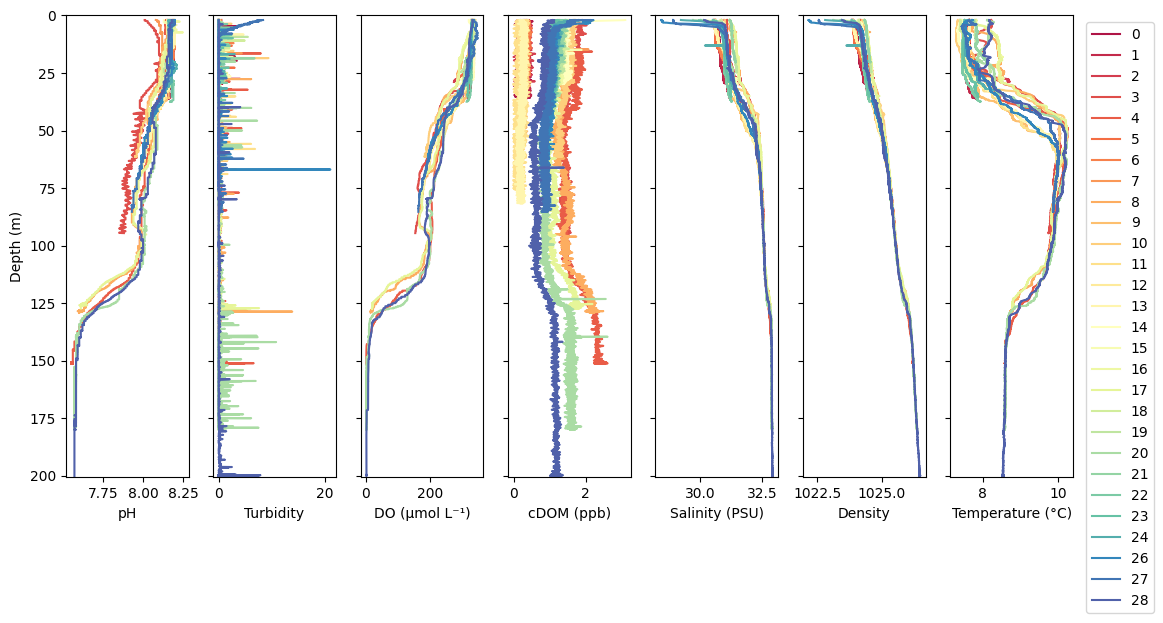

In [9]:
# Profiles excluded from the plot due to data quality issues.
# Profile 25: DO sensor malfunction during the cast.
EXCLUDED_PROFILES = [25]

# Axis labels with units for each measured variable
AXIS_LABELS = {
    'TempCT':   'Temperature (\u00b0C)',
    'Salinity': 'Salinity (PSU)',
    'DO':       DO_LABEL,
    'DOM':      'cDOM (ppb)',
    'pH':       'pH',
}

# Drop instrument columns not used for profiling, plus any TEOS-10 derived columns
# added by a later cell. errors='ignore' means missing column names are silently skipped.
data = df.drop(
    ['Date', 'Time', 'Pressure', 'file', 'CalcSV', 'Cond', 'TempDO',
     'Chlorophyll', 'lat', 'lon', 'p', 'SA', 'CT', 'sigma0'],
    axis=1, errors='ignore'
)

fig, axs = plt.subplots(ncols=len(data.keys()) - 2, figsize=(13, 6), sharey=True)
ylim_max = max(data['Depth']) + 0.5
for ax in axs:
    ax.set_ylim(ylim_max, 0)
axs[0].set_ylabel('Depth (m)')

for ind, CTD in data.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    for i, key in enumerate(CTD.keys()):
        if key in ['Depth', 'profile']:
            continue
        elif key == 'DO':
            axs[i - 1].plot(CTD['DO'] / DO_DIVISOR, CTD['Depth'],
                            color=PROFILE_COLORS[ind], label=ind)
            axs[i - 1].set_xlabel(AXIS_LABELS['DO'])
        else:
            axs[i - 1].plot(key, 'Depth', data=CTD,
                            color=PROFILE_COLORS[ind], label=ind)
            axs[i - 1].set_xlabel(AXIS_LABELS.get(key, key))

axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Density Profiles and Mixed Layer Depth

**Potential density anomaly** (σ₀, kg m⁻³) is the density a water parcel would have if raised adiabatically to the surface. Using σ₀ rather than in-situ density removes the effect of compression, making values at different depths directly comparable.

The **mixed layer depth (MLD)** is defined here using the density threshold criterion of de Boyer Montégut et al. (2004): the shallowest depth at which σ₀ exceeds the near-surface (first measurement) value by more than 0.03 kg m⁻³. In winter (February), deep mixing typically produces a relatively deep mixed layer.

Mean MLD: 9.9 m  (range: 2.0–151.4 m)


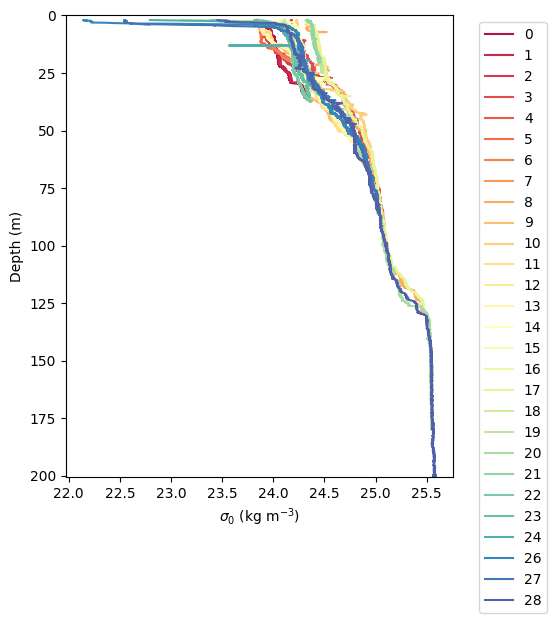

In [85]:
MLD_THRESHOLD = 0.03  # kg m⁻³ — density threshold criterion (de Boyer Montégut et al. 2004)

mld = {}
fig, ax = plt.subplots(figsize=(5, 6))
ax.set_ylim(max(df['Depth']) + 0.5, 0)
ax.set_ylabel('Depth (m)')
ax.set_xlabel('$\\sigma_0$ (kg m$^{-3}$)')

for ind, grp in df.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    ax.plot(grp['sigma0'], grp['Depth'], color=PROFILE_COLORS[ind], label=ind)

    # MLD: shallowest depth where sigma0 exceeds near-surface value by more than the threshold
    sigma_surf = grp['sigma0'].iloc[0]
    below = grp[grp['sigma0'] > sigma_surf + MLD_THRESHOLD]
    mld[ind] = below['Depth'].iloc[0] if len(below) > 0 else grp['Depth'].max()

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

mld_vals = list(mld.values())
print(f'Mean MLD: {np.mean(mld_vals):.1f} m  '
      f'(range: {min(mld_vals):.1f}\u2013{max(mld_vals):.1f} m)')

## Stratification: Brunt–Väisälä Frequency

The **Brunt–Väisälä frequency squared** (N²) measures the resistance of the water column to vertical displacement:

$$N^2 = -\frac{g}{\rho_0}\frac{\partial \sigma_0}{\partial z}$$

- **Large N²** — strong stratification; parcels displaced vertically are quickly restored.  
- **N² ≈ 0** — the mixed layer, where density is nearly uniform and vertical mixing is easy.  
- **N² < 0** — gravitational instability (rarely observed in CTD data as it mixes away immediately).

N² is computed from adjacent data points using `gsw.Nsquared`, so each profile produces *n*−1 values plotted at mid-depth between consecutive measurements.

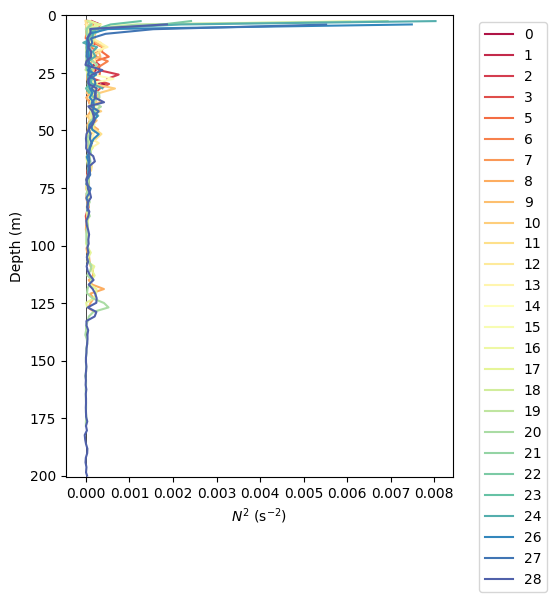

In [90]:
N2_BIN_WIDTH = 2  # dbar — pressure bin width for averaging SA and CT before computing N²

fig, ax = plt.subplots(figsize=(5, 6))
ax.set_ylim(max(df['Depth']) + 0.5, 0)
ax.set_ylabel('Depth (m)')
ax.set_xlabel('$N^2$ (s$^{-2}$)')
ax.axvline(0, color='k', linewidth=0.5)

for ind, grp in df.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    grp_clean = grp.dropna(subset=['SA', 'CT', 'p'])
    grp_clean = grp_clean[grp_clean['p'].diff().fillna(1) > 0]
    if len(grp_clean) < 2:
        continue

    # Bin-average SA, CT, p, and lat into pressure bins before computing N².
    # Calculating N² from raw high-resolution CTD data produces very noisy
    # results because it depends on the density gradient between adjacent
    # points. Averaging into ~2 dbar bins first suppresses this noise while
    # preserving real vertical structure.
    p_max = grp_clean['p'].max()
    bins   = np.arange(0, p_max + N2_BIN_WIDTH, N2_BIN_WIDTH)
    labels = (bins[:-1] + bins[1:]) / 2
    grp_clean = grp_clean.copy()
    grp_clean['p_bin'] = pd.cut(grp_clean['p'], bins=bins, labels=labels)
    binned = (grp_clean.groupby('p_bin', observed=True)[['SA', 'CT', 'p', 'lat']]
                        .mean()
                        .dropna())
    if len(binned) < 2:
        continue

    N2, p_mid = gsw.Nsquared(
        binned['SA'].values,
        binned['CT'].values,
        binned['p'].values,
        lat=binned['lat'].values
    )
    z_mid = -gsw.z_from_p(p_mid, binned['lat'].iloc[0])
    ax.plot(N2, z_mid, color=PROFILE_COLORS[ind], label=ind)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Oxygen Saturation

The solubility of oxygen in seawater depends on temperature and salinity: colder, fresher water can hold more dissolved oxygen.  
**Oxygen saturation** expresses the measured concentration as a percentage of the equilibrium solubility at the same T and S:

$$\text{O}_2\% = \frac{[\text{DO}]_\text{measured}}{[\text{DO}]_\text{sat}(T,\, S)} \times 100$$

- $\text{O}_2\% > 100\%$ — **supersaturation**: excess oxygen, typically from photosynthesis near the surface.
- $\text{O}_2\% < 100\%$ — **undersaturation**: oxygen has been consumed, e.g. by respiration or organic matter decomposition.

The saturation concentration is computed using the Garcia & Gordon (1992) equation via `gsw.O2sol_SP_pt`. The dashed line in panel **B** marks 100% saturation.

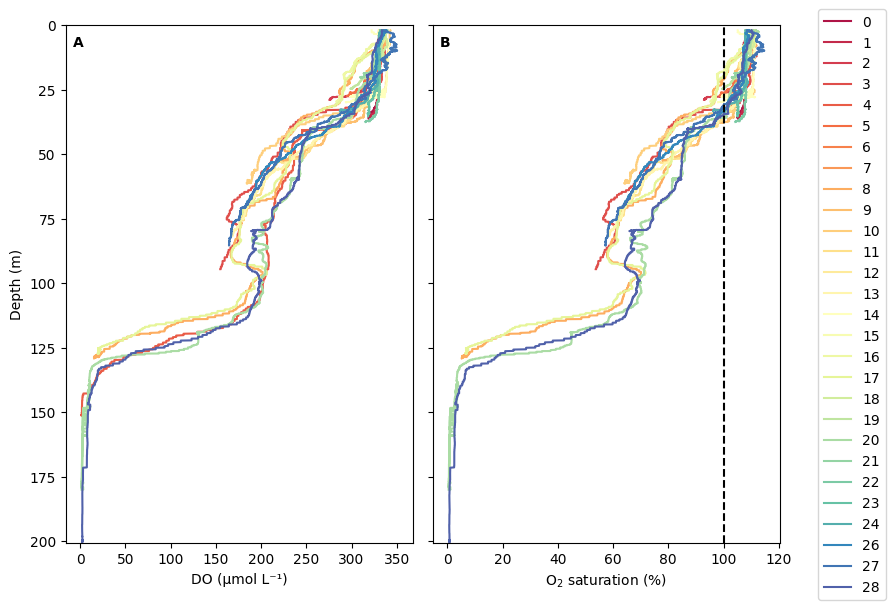

In [91]:
# Potential temperature from TEOS-10 Conservative Temperature
pt = gsw.pt_from_CT(df['SA'], df['CT'])

# O2 saturation in µmol/kg (Garcia & Gordon 1992) using proper potential temperature
o2_sat_umolkg = gsw.O2sol_SP_pt(df['Salinity'], pt)

# Convert to µmol/L using in-situ density from TEOS-10 quantities
rho_kgL      = gsw.rho(df['SA'], df['CT'], df['p']) / 1000
o2_sat_umolL = o2_sat_umolkg * rho_kgL

# Percent saturation (unit-independent)
o2_pct = (df['DO'] / o2_sat_umolL) * 100

# Plot DO profiles alongside percent saturation
fig, axs = plt.subplots(ncols=2, figsize=(8, 6), sharey=True)
ylim_max = max(df['Depth']) + 0.5
for ax in axs:
    ax.set_ylim(ylim_max, 0)
axs[0].set_ylabel('Depth (m)')

for ind, grp in df.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    axs[0].plot(grp['DO'] / DO_DIVISOR, grp['Depth'], color=PROFILE_COLORS[ind], label=ind)
    axs[1].plot(o2_pct[grp.index], grp['Depth'], color=PROFILE_COLORS[ind])

axs[0].set_xlabel(DO_LABEL)
axs[1].set_xlabel('O$_2$ saturation (%)')
axs[1].axvline(100, color='k', linestyle='--')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left')
fig.tight_layout()

for ax, lbl in zip(axs, 'AB'):
    ax.text(0.02, 0.98, lbl, transform=ax.transAxes,
            va='top', ha='left', fontweight='bold')

## Apparent Oxygen Utilization (AOU)

**Apparent Oxygen Utilization** is the difference between the saturation concentration and the measured concentration:

$$\text{AOU} = [\text{DO}]_\text{sat}(T,\, S) - [\text{DO}]_\text{measured}$$

- **AOU > 0** — oxygen consumed since last atmospheric contact; signature of net respiration or organic matter remineralisation.  
- **AOU < 0** — oxygen produced in excess of saturation; signature of net photosynthesis.  
- **AOU ≈ 0** — water close to atmospheric equilibrium.

AOU is reported in µmol L⁻¹ regardless of the `DO_UNITS` setting, and the dashed line marks zero.

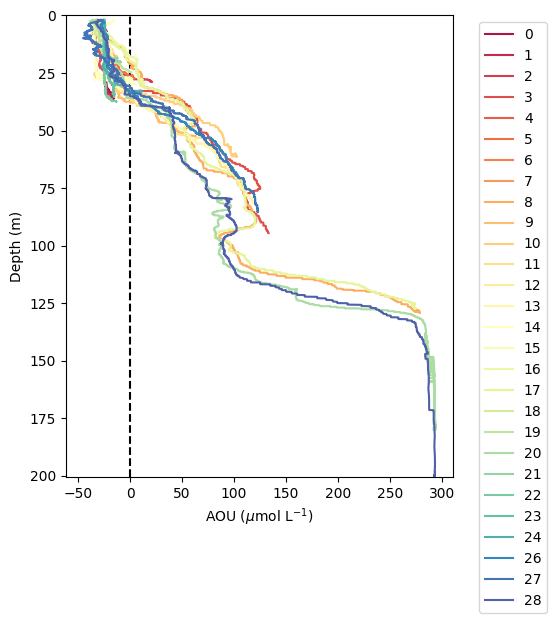

In [92]:
# AOU in µmol/L — always in these units regardless of DO_UNITS setting
aou = o2_sat_umolL - df['DO']

fig, ax = plt.subplots(figsize=(5, 6))
ax.set_ylim(max(df['Depth']) + 0.5, 0)
ax.set_ylabel('Depth (m)')
ax.set_xlabel('AOU ($\\mu$mol L$^{-1}$)')
ax.axvline(0, color='k', linestyle='--')

for ind, grp in df.groupby('profile'):
    if ind in EXCLUDED_PROFILES:
        continue
    ax.plot(aou[grp.index], grp['Depth'], color=PROFILE_COLORS[ind], label=ind)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Temperature–Salinity (T-S) Diagram

A **T-S diagram** plots temperature against salinity for every data point across all casts.  
Because seawater density depends primarily on these two variables, contours of constant density (**isopycnals**, dashed lines, units: kg m⁻³ − 1000) are overlaid.

- Points falling along the same isopycnal have equal density regardless of their individual temperature and salinity values.
- Distinct water masses appear as clusters; mixing between two water masses appears as a straight line connecting them.
- Colour indicates dissolved oxygen concentration.

5.79081927143404 11.30449070290343


Text(0, 0.5, 'Conservative Temperature (°C)')

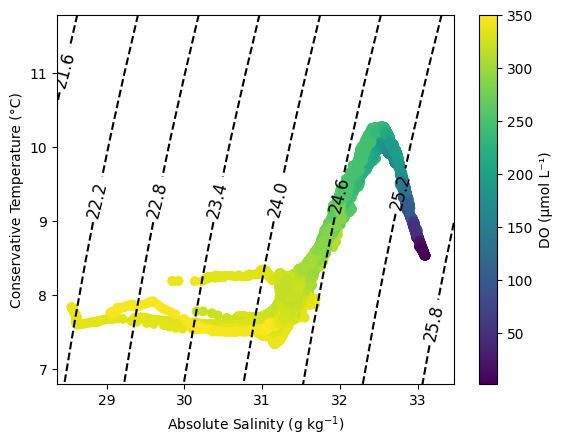

In [98]:
# Exclude profiles with data quality issues
df_ts = df[~df['profile'].isin(EXCLUDED_PROFILES)]

# Calculate boundaries of the T-S space using TEOS-10 quantities
smin = df_ts['SA'].min() - (0.01 * df_ts['SA'].min())
smax = df_ts['SA'].max() + (0.01 * df_ts['SA'].max())
tmin = df_ts['CT'].min() - (0.15 * df_ts['CT'].max())
tmax = df_ts['CT'].max() + (0.1  * df_ts['CT'].max())

print(tmin, tmax)

# Create SA and CT vectors of appropriate dimensions for the density grid
xdim = int(round((smax - smin) / 0.1 + 1, 0))
ydim = int(round((tmax - tmin) + 1, 0))
ti = np.linspace(1, ydim - 1, ydim) + tmin
si = np.linspace(1, xdim - 1, xdim) * 0.1 + smin

# Compute sigma-0 on a 2-D grid (vectorised)
SI, TI = np.meshgrid(si, ti)
dens = gsw.sigma0(SI, TI)

TS_COLOR = 0 # can replace 0 with 'depth' to plot depth instead of DO on the TS plot

# Colour variable
if TS_COLOR == 'depth':
    c_var = df_ts['Depth']
    c_lbl = 'Depth (m)'
    c_kw  = {'cmap': cmocean.cm.deep}
else:
    c_var = df_ts['DO'] / DO_DIVISOR
    c_lbl = DO_LABEL
    c_kw  = {}

# Plot
fig, ax0 = plt.subplots()
CS = ax0.contour(si, ti, dens, linestyles='dashed', colors='k')
plt.clabel(CS, fontsize=12, inline=1, fmt='%1.1f')

c = ax0.scatter(df_ts['SA'], df_ts['CT'], c=c_var, **c_kw)
fig.colorbar(c, ax=ax0, label=c_lbl)

ax0.set_xlabel('Absolute Salinity (g kg$^{-1}$)')
ax0.set_ylabel('Conservative Temperature (\u00b0C)')